In [ ]:
!pip install albumentations -q
from google.colab import drive
drive.mount('/content/drive')
import os
# Change this path to wherever you added the shortcut in your Drive
IMAGE_DIR = '/content/drive/MyDrive/images'
CSV_PATH = '/content/drive/MyDrive/role_challenge_dataset_ground_truth.csv'

print(len(os.listdir(IMAGE_DIR)), "images found")

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

In [ ]:
import pandas as pd

# Cell 3 - Dataset

IMAGE_DIR = '/content/drive/MyDrive/images'
CSV_PATH = '/content/drive/MyDrive/role_challenge_dataset_ground_truth.csv'

IMAGE_SIZE = 224  # standard size for pretrained models

class LandmarkDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, row['image_name'])
        image = Image.open(img_path).convert('RGB')
        orig_w, orig_h = image.size

        if self.transform:
            image = self.transform(image)

        # Normalize coordinates to 0-1 range
        landmarks = np.array([
            row['ofd_1_x'] / orig_w, row['ofd_1_y'] / orig_h,
            row['ofd_2_x'] / orig_w, row['ofd_2_y'] / orig_h,
            row['bpd_1_x'] / orig_w, row['bpd_1_y'] / orig_h,
            row['bpd_2_x'] / orig_w, row['bpd_2_y'] / orig_h,
        ], dtype=np.float32)

        return image, torch.tensor(landmarks)

# Load CSV and split train/val
df = pd.read_csv(CSV_PATH)
print(f"Total samples: {len(df)}")

train_df = df.sample(frac=0.85, random_state=42)
val_df = df.drop(train_df.index)
print(f"Train: {len(train_df)}, Val: {len(val_df)}")

# Transforms - Hypothesis 1 (no augmentation, baseline)
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = LandmarkDataset(train_df, IMAGE_DIR, train_transform)
val_dataset = LandmarkDataset(val_df, IMAGE_DIR, val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

print("Dataset ready!")

In [ ]:
# ============================================================
# Cell 4 — Model Architecture (FIXED: Sigmoid removed)
# ============================================================

import torch
import torch.nn as nn
from torchvision import models

class LandmarkDetector(nn.Module):
    def __init__(self, backbone_name='resnet18', num_landmarks=4, pretrained=True):
        super(LandmarkDetector, self).__init__()

        if backbone_name == 'resnet18':
            base = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
            in_features = base.fc.in_features
            base.fc = nn.Identity()
            self.backbone = base

        elif backbone_name == 'efficientnet_b0':
            base = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
            in_features = base.classifier[1].in_features
            base.classifier = nn.Identity()
            self.backbone = base

        else:
            raise ValueError(f"Unknown backbone: {backbone_name}")

        self.head = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_landmarks * 2)
            # NO Sigmoid — raw linear output lets the network
            # converge freely without gradient saturation at edges
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)   # raw values, no squashing


device = 'cuda' if torch.cuda.is_available() else 'cpu'
dummy = torch.randn(1, 3, 224, 224).to(device)

for name in ['resnet18', 'efficientnet_b0']:
    m = LandmarkDetector(backbone_name=name).to(device)
    out = m(dummy)
    print(f"{name:20s} → output shape: {out.shape}")

print("\n✅ Cell 4 done — Sigmoid removed from both backbones!")

In [ ]:
# ============================================================
# Cell 5 — Training Loop
# ============================================================

import torch.optim as optim

def train_model(model, train_loader, val_loader,
                loss_fn, num_epochs=20, lr=1e-4, variation_name="V1"):

    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=3, factor=0.5
    )

    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')

    print(f"\n{'='*50}")
    print(f"  Training: {variation_name}")
    print(f"{'='*50}")

    for epoch in range(num_epochs):
        # TRAIN
        model.train()
        train_loss = 0.0
        for images, landmarks in train_loader:
            images = images.to(device)
            landmarks = landmarks.to(device)
            optimizer.zero_grad()
            predictions = model(images)
            loss = loss_fn(predictions, landmarks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        # VALIDATE
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, landmarks in val_loader:
                images = images.to(device)
                landmarks = landmarks.to(device)
                predictions = model(images)
                val_loss += loss_fn(predictions, landmarks).item()
        val_loss /= len(val_loader)

        scheduler.step(val_loss)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), f'best_{variation_name}.pth')
            tag = " ← best"
        else:
            tag = ""

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Epoch [{epoch+1:02d}/{num_epochs}] "
                  f"Train: {train_loss:.4f} | Val: {val_loss:.4f}{tag}")

    print(f"\n  Best Val Loss: {best_val_loss:.4f}")
    print(f"  Model saved as: best_{variation_name}.pth")
    return history


mse_loss      = nn.MSELoss()
smoothl1_loss = nn.SmoothL1Loss()

print("✅ Cell 5 done — training loop ready!")
print(f"   Device: {device}")
print(f"   Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

In [ ]:
# ============================================================
# Cell 6 — Run All 3 Variations
# FIXED: V3 uses albumentations so image + landmarks
#        are transformed together (no coordinate corruption)
# ============================================================

import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
from torch.utils.data import Dataset, DataLoader
import pandas as pd

IMAGE_SIZE = 224

# ── Albumentations pipeline: spatial ops are keypoint-aware ──
aug_transform_v3 = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=10, p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
], keypoint_params=A.KeypointParams(format='xy', remove_invisible=False))

eval_transform_v3 = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
], keypoint_params=A.KeypointParams(format='xy', remove_invisible=False))


class LandmarkDatasetV3(Dataset):
    """
    Albumentations dataset — image and landmark coordinates
    are transformed simultaneously so they always stay in sync.
    """
    def __init__(self, df, image_dir, augment=False):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = aug_transform_v3 if augment else eval_transform_v3

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, row['image_name'])

        # Albumentations needs HWC uint8 numpy array
        image = np.array(Image.open(img_path).convert('RGB'))
        orig_h, orig_w = image.shape[:2]

        # Landmarks in PIXEL space — albumentations moves them with the image
        keypoints = [
            (float(row['ofd_1_x']), float(row['ofd_1_y'])),
            (float(row['ofd_2_x']), float(row['ofd_2_y'])),
            (float(row['bpd_1_x']), float(row['bpd_1_y'])),
            (float(row['bpd_2_x']), float(row['bpd_2_y'])),
        ]

        result = self.transform(image=image, keypoints=keypoints)
        image_t = result['image']       # (3, 224, 224) float32 tensor
        kps_out = result['keypoints']   # list of (x, y) in post-transform space

        # Normalise to [0,1] AFTER augmentation
        landmarks = []
        for (x, y) in kps_out:
            landmarks.append(x / IMAGE_SIZE)
            landmarks.append(y / IMAGE_SIZE)

        return image_t, torch.tensor(landmarks, dtype=torch.float32)


# ── Reload split (same seed = same split as before) ──────────
df = pd.read_csv(CSV_PATH)
train_df = df.sample(frac=0.85, random_state=42).reset_index(drop=True)
val_df   = df.drop(train_df.index).reset_index(drop=True)

train_dataset_v3 = LandmarkDatasetV3(train_df, IMAGE_DIR, augment=True)
val_dataset_v3   = LandmarkDatasetV3(val_df,   IMAGE_DIR, augment=False)
train_loader_v3  = DataLoader(train_dataset_v3, batch_size=16, shuffle=True)
val_loader_v3    = DataLoader(val_dataset_v3,   batch_size=16, shuffle=False)

mse_loss      = nn.MSELoss()
smoothl1_loss = nn.SmoothL1Loss()

all_histories = {}

# ── V1: ResNet-18 + MSE ───────────────────────────────────────
print("Starting Variation 1...")
model_v1 = LandmarkDetector(backbone_name='resnet18').to(device)
history_v1 = train_model(model_v1, train_loader, val_loader,
                          loss_fn=mse_loss, num_epochs=20,
                          variation_name="V1_ResNet_MSE")
all_histories['V1'] = history_v1

# ── V2: ResNet-18 + SmoothL1 ─────────────────────────────────
print("\nStarting Variation 2...")
model_v2 = LandmarkDetector(backbone_name='resnet18').to(device)
history_v2 = train_model(model_v2, train_loader, val_loader,
                          loss_fn=smoothl1_loss, num_epochs=20,
                          variation_name="V2_ResNet_SmoothL1")
all_histories['V2'] = history_v2

# ── V3: EfficientNet-B0 + SmoothL1 + correct augmentation ────
print("\nStarting Variation 3...")
model_v3 = LandmarkDetector(backbone_name='efficientnet_b0').to(device)
history_v3 = train_model(model_v3, train_loader_v3, val_loader_v3,
                          loss_fn=smoothl1_loss, num_epochs=20,
                          variation_name="V3_EfficientNet_Aug")
all_histories['V3'] = history_v3

print("\n" + "="*50)
print("  ALL 3 VARIATIONS COMPLETE")
print("="*50)

In [ ]:
# ============================================================
# Cell 7 — Results Table + Visual Predictions + BPD/OFD
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# ── 1. RESULTS SUMMARY TABLE ─────────────────────────────────
print("=" * 55)
print(f"  {'Variation':<30} {'Best Val Loss':>12}")
print("=" * 55)
results = {
    'V1: ResNet-18 + MSE':          min(all_histories['V1']['val_loss']),
    'V2: ResNet-18 + SmoothL1':     min(all_histories['V2']['val_loss']),
    'V3: EfficientNet + Aug':       min(all_histories['V3']['val_loss']),
}
for name, loss in results.items():
    print(f"  {name:<30} {loss:>12.4f}")
print("=" * 55)

best_var = min(results, key=results.get)
print(f"\n  Best variation: {best_var}")

# ── 2. LOSS CURVES ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, history) in zip(axes, [
    ('V1: ResNet+MSE',      all_histories['V1']),
    ('V2: ResNet+SmoothL1', all_histories['V2']),
    ('V3: EfficientNet+Aug',all_histories['V3'])
]):
    ax.plot(history['train_loss'], label='Train', color='steelblue')
    ax.plot(history['val_loss'],   label='Val',   color='orangered')
    ax.set_title(name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training vs Validation Loss — All 3 Variations',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Loss curves saved!")

# ── 3. VISUAL PREDICTION OVERLAY ─────────────────────────────
# Load best model (V3) and show predictions vs ground truth

best_model = LandmarkDetector(backbone_name='efficientnet_b0').to(device)
best_model.load_state_dict(torch.load('best_V3_EfficientNet_Aug.pth'))
best_model.eval()

# Get one batch from val loader
images, true_landmarks = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    pred_landmarks = best_model(images).cpu().numpy()

true_landmarks = true_landmarks.numpy()

# Plot first 4 images
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, ax in enumerate(axes):
    # Denormalize image for display
    img = images[i].cpu().permute(1, 2, 0).numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)
    ax.imshow(img, cmap='gray')

    # Scale coords back to pixel space (224x224)
    true_pts  = true_landmarks[i].reshape(4, 2) * 224
    pred_pts  = pred_landmarks[i].reshape(4, 2) * 224

    # Plot ground truth (red) and predictions (blue)
    labels_gt   = ['OFD1','OFD2','BPD1','BPD2']
    for j, (tp, pp) in enumerate(zip(true_pts, pred_pts)):
        ax.plot(*tp, 'r+', markersize=10, markeredgewidth=2)
        ax.plot(*pp, 'b+', markersize=10, markeredgewidth=2)
        # Line showing error
        ax.plot([tp[0], pp[0]], [tp[1], pp[1]],
                'yellow', linewidth=1, alpha=0.7)

    ax.set_title(f'Sample {i+1}', fontsize=9)
    ax.axis('off')

# Legend
from matplotlib.lines import Line2D
legend = [Line2D([0],[0], marker='+', color='r',
                 label='Ground Truth', markersize=8),
          Line2D([0],[0], marker='+', color='b',
                 label='Predicted', markersize=8),
          Line2D([0],[0], color='yellow',
                 label='Error gap', linewidth=1)]
fig.legend(handles=legend, loc='lower center', ncol=3, fontsize=10)
plt.suptitle('Predicted vs Ground Truth Landmarks (Best Model: V3)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('predictions_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Prediction overlay saved!")

# ── 4. BPD / OFD DISTANCE COMPUTATION ────────────────────────
print("\n" + "="*55)
print("  BPD / OFD Clinical Measurement Comparison")
print("="*55)
print(f"  {'Sample':<10} {'True BPD':>10} {'Pred BPD':>10} "
      f"{'True OFD':>10} {'Pred OFD':>10}")
print("-"*55)

for i in range(min(6, len(true_landmarks))):
    t = true_landmarks[i].reshape(4, 2) * 224
    p = pred_landmarks[i].reshape(4, 2) * 224

    # OFD = distance between points 0 and 1
    true_ofd = np.sqrt((t[1,0]-t[0,0])**2 + (t[1,1]-t[0,1])**2)
    pred_ofd = np.sqrt((p[1,0]-p[0,0])**2 + (p[1,1]-p[0,1])**2)

    # BPD = distance between points 2 and 3
    true_bpd = np.sqrt((t[3,0]-t[2,0])**2 + (t[3,1]-t[2,1])**2)
    pred_bpd = np.sqrt((p[3,0]-p[2,0])**2 + (p[3,1]-p[2,1])**2)

    print(f"  {i+1:<10} {true_bpd:>10.1f} {pred_bpd:>10.1f} "
          f"{true_ofd:>10.1f} {pred_ofd:>10.1f}")

print("="*55)
print("  (values in pixels at 224×224 resolution)")
print("\n✅ Cell 7 complete — Part A done!")

In [ ]:
# ============================================================
# Cell 8 — Part B: U-Net Architecture for Skull Segmentation
# Input:  (batch, 3, 224, 224) — RGB ultrasound image
# Output: (batch, 1, 224, 224) — binary mask (skull or not)
# ============================================================

class DoubleConv(nn.Module):
    """Two conv layers back to back — the basic U-Net building block"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    """
    U-Net: Encoder compresses image → Decoder rebuilds mask
    Skip connections pass detail from encoder to decoder
    Think of it as: zoom out to understand → zoom back in to draw
    """
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()

        # ── ENCODER (going down — extract features) ───────────
        self.enc1 = DoubleConv(in_channels, 64)   # 224→224
        self.enc2 = DoubleConv(64, 128)            # 112→112
        self.enc3 = DoubleConv(128, 256)           # 56→56
        self.enc4 = DoubleConv(256, 512)           # 28→28

        self.pool = nn.MaxPool2d(2)                # halves spatial size

        # ── BOTTLENECK (smallest, most abstract) ──────────────
        self.bottleneck = DoubleConv(512, 1024)    # 14→14

        # ── DECODER (going up — rebuild spatial detail) ───────
        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = DoubleConv(1024, 512)  # 1024 because skip connection

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        # ── OUTPUT ────────────────────────────────────────────
        # 1x1 conv → single channel mask
        self.final = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder — save each level for skip connections
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck
        b = self.bottleneck(self.pool(e4))

        # Decoder — upsample + concatenate skip connection
        d4 = self.dec4(torch.cat([self.up4(b),  e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.final(d1)  # raw logits — no sigmoid here


# ── SANITY CHECK ──────────────────────────────────────────────
unet = UNet(in_channels=3, out_channels=1).to(device)
dummy = torch.randn(1, 3, 224, 224).to(device)
out = unet(dummy)

print(f"U-Net output shape: {out.shape}")  # expect (1, 1, 224, 224)
print(f"Parameters: {sum(p.numel() for p in unet.parameters()):,}")
print("✅ Cell 8 done — U-Net ready!")

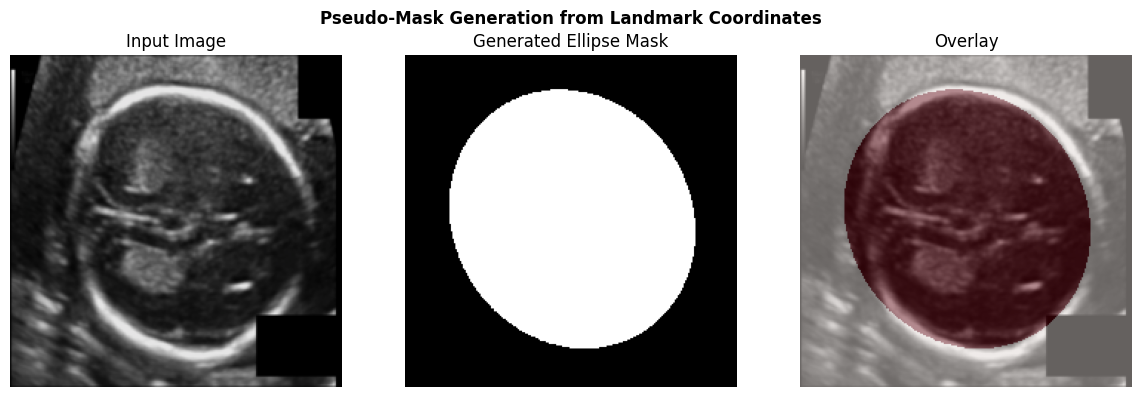

✅ Mask generation working!
   Train: 529 | Val: 93

  Training U-Net (Part B)
  Epoch [01/20] Train: 0.7967 | Val: 0.4327 ← best
  Epoch [05/20] Train: 0.4793 | Val: 0.3124
  Epoch [10/20] Train: 0.3632 | Val: 0.2435
  Epoch [15/20] Train: 0.2804 | Val: 0.1728 ← best
  Epoch [20/20] Train: 0.2159 | Val: 0.1567 ← best

  Best Val Loss: 0.1567
  Model saved as: best_unet.pth

✅ Cell 9 complete — U-Net trained!


In [16]:
# ============================================================
# Cell 9 — Generate Pseudo-Masks + Train U-Net
# Strategy: fit ellipse to 4 landmark coords → binary mask
# No separate mask files needed — derived from CSV directly
# ============================================================

import cv2
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

# ── SEGMENTATION DATASET ──────────────────────────────────────
class SegmentationDataset(Dataset):
    """
    Generates binary skull masks on the fly from landmark coords.
    Fits an ellipse through the 4 BPD/OFD points and fills it.
    """
    def __init__(self, df, image_dir, image_size=224, augment=False):
        self.df         = df.reset_index(drop=True)
        self.image_dir  = image_dir
        self.image_size = image_size
        self.augment    = augment

        self.img_transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                 [0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.df)

    def _make_mask(self, row, orig_w, orig_h):
        # Get 4 points in original pixel space
        points = np.array([
            [row['ofd_1_x'], row['ofd_1_y']],
            [row['ofd_2_x'], row['ofd_2_y']],
            [row['bpd_1_x'], row['bpd_1_y']],
            [row['bpd_2_x'], row['bpd_2_y']],
        ], dtype=np.float32)

        mask = np.zeros((orig_h, orig_w), dtype=np.uint8)

        # Compute ellipse center and axes from BPD/OFD directly
        center_x = int(points[:, 0].mean())
        center_y = int(points[:, 1].mean())

        # OFD axis = half distance between OFD points
        ofd_axis = int(np.sqrt((points[1,0]-points[0,0])**2 +
                                (points[1,1]-points[0,1])**2) / 2)

        # BPD axis = half distance between BPD points
        bpd_axis = int(np.sqrt((points[3,0]-points[2,0])**2 +
                                (points[3,1]-points[2,1])**2) / 2)

        # Compute rotation angle from OFD direction
        angle = np.degrees(np.arctan2(
            points[1,1] - points[0,1],
            points[1,0] - points[0,0]
        ))

        # Draw filled ellipse
        cv2.ellipse(mask,
                    (center_x, center_y),
                    (max(ofd_axis, 1), max(bpd_axis, 1)),
                    angle, 0, 360, 255, -1)

        mask = cv2.resize(mask, (self.image_size, self.image_size),
                         interpolation=cv2.INTER_NEAREST)

        return torch.tensor(mask / 255.0, dtype=torch.float32).unsqueeze(0)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, row['image_name'])
        image    = Image.open(img_path).convert('RGB')
        orig_w, orig_h = image.size

        # Apply image transforms
        image = self.img_transform(image)

        # Generate mask from landmarks
        mask = self._make_mask(row, orig_w, orig_h)

        return image, mask


# ── BUILD DATALOADERS ─────────────────────────────────────────
seg_train = SegmentationDataset(train_df, IMAGE_DIR, augment=True)
seg_val   = SegmentationDataset(val_df,   IMAGE_DIR, augment=False)

seg_train_loader = DataLoader(seg_train, batch_size=8, shuffle=True)
seg_val_loader   = DataLoader(seg_val,   batch_size=8, shuffle=False)

# Quick check — visualize one generated mask
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
sample_img, sample_mask = seg_train[0]

# Show original image
img_display = sample_img.permute(1,2,0).numpy()
img_display = img_display * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])
img_display = np.clip(img_display, 0, 1)
axes[0].imshow(img_display)
axes[0].set_title('Input Image')
axes[0].axis('off')

# Show generated mask
axes[1].imshow(sample_mask.squeeze(), cmap='gray')
axes[1].set_title('Generated Ellipse Mask')
axes[1].axis('off')

# Show overlay
axes[2].imshow(img_display)
axes[2].imshow(sample_mask.squeeze(), cmap='Reds', alpha=0.4)
axes[2].set_title('Overlay')
axes[2].axis('off')

plt.suptitle('Pseudo-Mask Generation from Landmark Coordinates',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('mask_sample.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Mask generation working!")
print(f"   Train: {len(seg_train)} | Val: {len(seg_val)}")


# ── U-NET TRAINING LOOP ───────────────────────────────────────
def train_unet(model, train_loader, val_loader, num_epochs=20):
    """
    Loss: BCE + Dice combined
    BCE  = pixel-wise cross entropy (is each pixel correct?)
    Dice = overlap between predicted and true mask (shape match)
    Together they give sharper, more complete segmentation
    """
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=3, factor=0.5
    )

    def dice_loss(pred, target, smooth=1.0):
        pred   = torch.sigmoid(pred)
        pred   = pred.view(-1)
        target = target.view(-1)
        intersection = (pred * target).sum()
        return 1 - (2*intersection + smooth) / (pred.sum() + target.sum() + smooth)

    def combined_loss(pred, target):
        bce  = F.binary_cross_entropy_with_logits(pred, target)
        dice = dice_loss(pred, target)
        return bce + dice   # equal weighting

    best_val_loss = float('inf')
    history = {'train_loss': [], 'val_loss': []}

    print(f"\n{'='*50}")
    print(f"  Training U-Net (Part B)")
    print(f"{'='*50}")

    for epoch in range(num_epochs):
        # TRAIN
        model.train()
        train_loss = 0.0
        for images, masks in train_loader:
            images = images.to(device)
            masks  = masks.to(device)
            optimizer.zero_grad()
            preds = model(images)
            loss  = combined_loss(preds, masks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        # VALIDATE
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks  = masks.to(device)
                preds  = model(images)
                val_loss += combined_loss(preds, masks).item()
        val_loss /= len(val_loader)

        scheduler.step(val_loss)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_unet.pth')
            tag = " ← best"
        else:
            tag = ""

        if (epoch+1) % 5 == 0 or epoch == 0:
            print(f"  Epoch [{epoch+1:02d}/{num_epochs}] "
                  f"Train: {train_loss:.4f} | Val: {val_loss:.4f}{tag}")

    print(f"\n  Best Val Loss: {best_val_loss:.4f}")
    print(f"  Model saved as: best_unet.pth")
    return history


# ── RUN U-NET TRAINING ────────────────────────────────────────
unet_model   = UNet(in_channels=3, out_channels=1).to(device)
unet_history = train_unet(unet_model, seg_train_loader, seg_val_loader,
                          num_epochs=20)

print("\n✅ Cell 9 complete — U-Net trained!")


  Clinical Measurement Comparison (pixels @ 224×224)
  Sample    True BPD     A:BPD     B:BPD  True OFD     A:OFD     B:OFD
-----------------------------------------------------------------
  1             79.4      53.3      30.4      22.6     113.0      31.8
  2            142.0      69.7      60.8     186.2      55.5      94.3
  3             96.5      62.7      58.0      55.2      89.5      73.5
  4            105.9      48.6      38.8     126.8      69.3      63.6
  5            123.5      78.1      28.4      23.3      72.9      36.9
  6            165.9      64.3      72.7      36.7      39.4     127.8
  7             46.4      48.1      85.1     151.6      79.4     118.0
  8            123.0     165.5      72.3     147.3     128.2      85.8

  Mean Absolute Error — BPD:
    Part A (landmarks):  26.3 px
    Part B (U-Net mask): 19.3 px

  Mean Absolute Error — OFD:
    Part A (landmarks):  25.6 px
    Part B (U-Net mask): 17.1 px


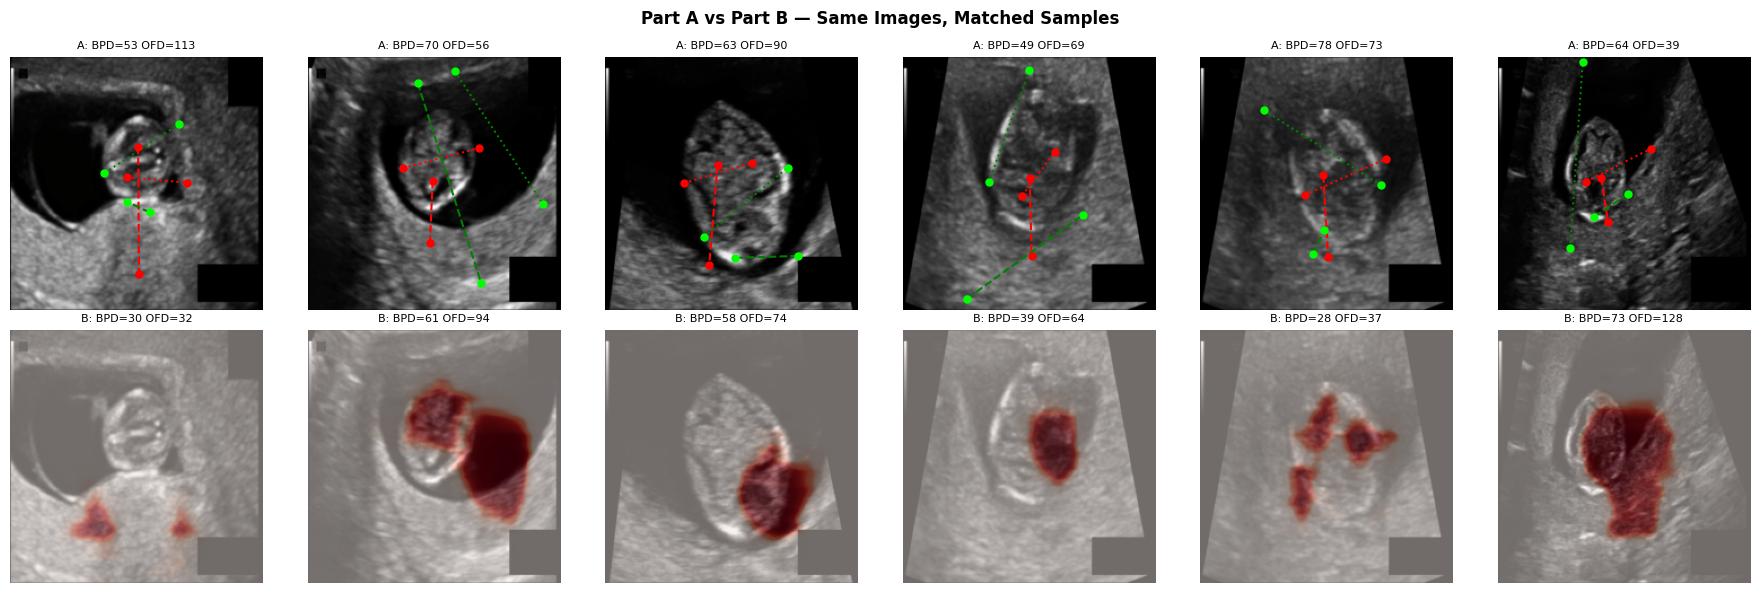


✅ Cell 10 complete — Full comparison done!
   Part A and Part B both complete!


In [17]:
# ============================================================
# Cell 10 — Ellipse Fitting + BPD/OFD Derivation from Mask
# FIXED: Single loader so image, true landmarks, and mask
#        predictions all come from the exact same sample index
# ============================================================

from scipy.ndimage import label

def derive_measurements_from_mask(mask_np):
    binary = (mask_np > 0.5).astype(np.uint8) * 255
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) == 0:
        return None, None, None
    largest = max(contours, key=cv2.contourArea)
    if len(largest) < 5:
        return None, None, None
    ellipse = cv2.fitEllipse(largest)
    center, axes, angle = ellipse
    ofd_pixels = max(axes)
    bpd_pixels = min(axes)
    return bpd_pixels, ofd_pixels, ellipse

def get_ellipse_endpoints(ellipse):
    (cx, cy), (major, minor), angle = ellipse
    angle_rad = np.radians(angle)
    ofd1 = (cx + (major/2)*np.cos(angle_rad), cy + (major/2)*np.sin(angle_rad))
    ofd2 = (cx - (major/2)*np.cos(angle_rad), cy - (major/2)*np.sin(angle_rad))
    bpd1 = (cx + (minor/2)*np.cos(angle_rad + np.pi/2), cy + (minor/2)*np.sin(angle_rad + np.pi/2))
    bpd2 = (cx - (minor/2)*np.cos(angle_rad + np.pi/2), cy - (minor/2)*np.sin(angle_rad + np.pi/2))
    return np.array([ofd1, ofd2, bpd1, bpd2])


# ── LOAD BEST MODELS ─────────────────────────────────────────
best_unet = UNet(in_channels=3, out_channels=1).to(device)
best_unet.load_state_dict(torch.load('best_unet.pth'))
best_unet.eval()

best_model.eval()

# ── SINGLE LOADER — guarantees sample i is the same image ────
# val_loader returns (image, landmarks) for every sample.
# We generate the mask from the same image on the fly using
# best_unet, so there is zero index mismatch.

partA_bpd, partA_ofd = [], []
partB_bpd, partB_ofd = [], []
true_bpd,  true_ofd  = [], []
vis_images, vis_lm_preds, vis_true_lm, vis_masks = [], [], [], []

with torch.no_grad():
    for images, landmarks in val_loader:
        images    = images.to(device)
        landmarks = landmarks.to(device)

        # Part A: landmark regression
        lm_preds = best_model(images).cpu().numpy()

        # Part B: segmentation — same images, so indices always match
        mask_logits = best_unet(images)
        mask_preds  = torch.sigmoid(mask_logits).cpu().numpy()

        true_lm_np = landmarks.cpu().numpy()

        for i in range(images.size(0)):
            # Part B measurement from predicted mask
            bpd_b, ofd_b, ellipse = derive_measurements_from_mask(mask_preds[i, 0])
            if bpd_b is None:
                continue

            partB_bpd.append(bpd_b)
            partB_ofd.append(ofd_b)

            # Part A measurement from predicted landmarks
            p = lm_preds[i].reshape(4, 2) * 224
            ofd_a = np.sqrt((p[1,0]-p[0,0])**2 + (p[1,1]-p[0,1])**2)
            bpd_a = np.sqrt((p[3,0]-p[2,0])**2 + (p[3,1]-p[2,1])**2)
            partA_bpd.append(bpd_a)
            partA_ofd.append(ofd_a)

            # True measurement from ground truth landmarks
            t = true_lm_np[i].reshape(4, 2) * 224
            true_ofd_val = np.sqrt((t[1,0]-t[0,0])**2 + (t[1,1]-t[0,1])**2)
            true_bpd_val = np.sqrt((t[3,0]-t[2,0])**2 + (t[3,1]-t[2,1])**2)
            true_bpd.append(true_bpd_val)
            true_ofd.append(true_ofd_val)

            # Collect up to 6 samples for visualisation
            if len(vis_images) < 6:
                vis_images.append(images[i].cpu())
                vis_lm_preds.append(lm_preds[i])
                vis_true_lm.append(true_lm_np[i])
                vis_masks.append(mask_preds[i, 0])


# ── COMPARISON TABLE ──────────────────────────────────────────
print("\n" + "="*65)
print("  Clinical Measurement Comparison (pixels @ 224×224)")
print("="*65)
print(f"  {'Sample':<8} {'True BPD':>9} {'A:BPD':>9} {'B:BPD':>9} "
      f"{'True OFD':>9} {'A:OFD':>9} {'B:OFD':>9}")
print("-"*65)
for i in range(min(8, len(true_bpd))):
    print(f"  {i+1:<8} {true_bpd[i]:>9.1f} {partA_bpd[i]:>9.1f} "
          f"{partB_bpd[i]:>9.1f} {true_ofd[i]:>9.1f} "
          f"{partA_ofd[i]:>9.1f} {partB_ofd[i]:>9.1f}")
print("="*65)

mae_a_bpd = np.mean(np.abs(np.array(partA_bpd) - np.array(true_bpd)))
mae_b_bpd = np.mean(np.abs(np.array(partB_bpd) - np.array(true_bpd)))
mae_a_ofd = np.mean(np.abs(np.array(partA_ofd) - np.array(true_ofd)))
mae_b_ofd = np.mean(np.abs(np.array(partB_ofd) - np.array(true_ofd)))

print(f"\n  Mean Absolute Error — BPD:")
print(f"    Part A (landmarks):  {mae_a_bpd:.1f} px")
print(f"    Part B (U-Net mask): {mae_b_bpd:.1f} px")
print(f"\n  Mean Absolute Error — OFD:")
print(f"    Part A (landmarks):  {mae_a_ofd:.1f} px")
print(f"    Part B (U-Net mask): {mae_b_ofd:.1f} px")


# ── VISUALISATION ─────────────────────────────────────────────
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

n_vis = len(vis_images)
fig, axes = plt.subplots(2, n_vis, figsize=(3*n_vis, 6))

for i in range(n_vis):
    # De-normalise image
    img = vis_images[i].permute(1,2,0).numpy()
    img = np.clip(img * std + mean, 0, 1)

    # Top row: Part A landmark overlay
    axes[0, i].imshow(img)
    p = vis_lm_preds[i].reshape(4, 2) * 224
    t = vis_true_lm[i].reshape(4, 2) * 224
    axes[0, i].scatter(p[:,0], p[:,1], c='red',  s=25, zorder=5, label='Pred')
    axes[0, i].scatter(t[:,0], t[:,1], c='lime', s=25, zorder=5, label='GT')
    axes[0, i].plot([p[0,0],p[1,0]], [p[0,1],p[1,1]], 'r--', lw=1.5)
    axes[0, i].plot([p[2,0],p[3,0]], [p[2,1],p[3,1]], 'r:',  lw=1.5)
    axes[0, i].plot([t[0,0],t[1,0]], [t[0,1],t[1,1]], 'g--', lw=1.5)
    axes[0, i].plot([t[2,0],t[3,0]], [t[2,1],t[3,1]], 'g:',  lw=1.5)
    axes[0, i].set_title(f'A: BPD={partA_bpd[i]:.0f} OFD={partA_ofd[i]:.0f}', fontsize=8)
    axes[0, i].axis('off')

    # Bottom row: Part B mask overlay
    axes[1, i].imshow(img)
    axes[1, i].imshow(vis_masks[i], cmap='Reds', alpha=0.45)
    axes[1, i].set_title(f'B: BPD={partB_bpd[i]:.0f} OFD={partB_ofd[i]:.0f}', fontsize=8)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Part A\n(Landmarks)', fontsize=9)
axes[1, 0].set_ylabel('Part B\n(U-Net)', fontsize=9)

plt.suptitle('Part A vs Part B — Same Images, Matched Samples', fontweight='bold')
plt.tight_layout()
plt.savefig('cell10_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Cell 10 complete — Full comparison done!")
print("   Part A and Part B both complete!")

In [18]:
from google.colab import files

files.download('best_V1_ResNet_MSE.pth')
files.download('best_V2_ResNet_SmoothL1.pth')
files.download('best_V3_EfficientNet_Aug.pth')
files.download('best_unet.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>